In [1]:
import pandas as pd
import numpy as np
import importlib

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely import wkt

import global_mapping as gm
import w1_tree as wt
import representation_metrics as rm 
import geotopics_plots as gtp

PATH = "../data_clean/"

In [2]:
df_country = pd.read_csv("../data/Floriana_country_info.csv")

df_cs = pd.read_csv(PATH+"df_country_subfield_roll_5y.csv", index_col=[0, 1, 2]).dropna(how="all")
df_cs.columns = df_cs.columns.astype(int)

year_list = df_cs.index.get_level_values(1).unique().sort_values().to_list()
country_list = df_cs.index.get_level_values(0).unique().sort_values().to_list()

year_list_10y = np.arange(2023, 1980, -5)
year_list_10y_rev = year_list_10y[::-1]

df_prob = df_cs.div(df_cs.sum(axis=1), axis=0)

df_total = (
    df_cs
    .sum(axis=1)
    .to_frame("total")
    .reset_index()
    .pivot(index=["country", "year"], columns=["mode"])
    .xs("total", axis=1)
    .assign(collab_share = lambda df: df.collaborative / (df.collaborative + df.individual))
)

df_dist = pd.read_csv(PATH+"df_dist_country.csv", index_col=[0, 1, 2])

In [3]:
world = gpd.read_file("../data_clean/world.csv")
world["geometry"] = world["geometry"].apply(wkt.loads)

world = gpd.GeoDataFrame(world, geometry="geometry", crs="EPSG:4326")

In [4]:
df_subfield = (
    pd.read_csv(PATH+"df_topics.csv")
    [["subfield_id", "subfield_name", "field_id", "field_name", "domain_id", "domain_name"]]
    .drop_duplicates()
    .sort_values(["domain_id", "field_id", "subfield_id"])
)
sf_list = df_subfield.subfield_id.to_list()

w1_tree = wt.W1Tree(df_subfield[["domain_id", "field_id", "subfield_id"]], weight_base=10.0)

In [ ]:
mode = "individual"
clustering = gm.GlobalMapping(df_dist.xs(mode, level=2),
                       df_prob.xs(mode, level=2),
                       df_total[[mode]].rename(columns={mode: "total"}), 
                       w1_tree.dist,
                       similarity_sigma=0.3, dyn_similarity_threshold=0.075)

cluster_list = clustering._df_mapping.dynamic_cluster.sort_values().drop_duplicates().to_list()
cluster_list_short = clustering._df_mapping.query("(year in @year_list_10y)").dynamic_cluster.sort_values().drop_duplicates().to_list()

df_prob_clusters = (
    df_prob.xs(mode, level=2)
    .merge(clustering._df_mapping[["country", "year", "dynamic_cluster"]], left_index=True, right_on=["country", "year"], how="right")
    .set_index(["country", "year", "dynamic_cluster"])
)

interest_metric = rm.SpecificityMetric(np.log(df_prob_clusters.replace({0: np.nan})))
interest_metric.get_metric(level_agg = 2, level_norm = 1)
interest_metric.get_pos_metric(0)
interest_metric.get_pos_metric_norm()

In [6]:
cmap = mcolors.LinearSegmentedColormap.from_list(
    name="test",
    colors=[
        (0, "white"),
        (0.4, "#E0929C"),
        (0.8, "#7A1F2B"),
        (1, "#472025")
    ]
)
colors = cmap(np.linspace(0.15, 1, len(cluster_list_short)))
color_dict_cmap = dict(zip(cluster_list_short, colors))

color_dict = {
    "individual": {
        -1: "#9D9D9D",
        0: "#203B47",
        1: colors[2],
        3: colors[1],
        4: colors[3],
        5: "#93A6AD",
    },
}
color_dict_tmp = color_dict["individual"]

# for i in range(len(color_dict_tmp.keys())):
#     plt.bar(i, 1, color=color_dict_tmp[list(color_dict_tmp.keys())[i]])

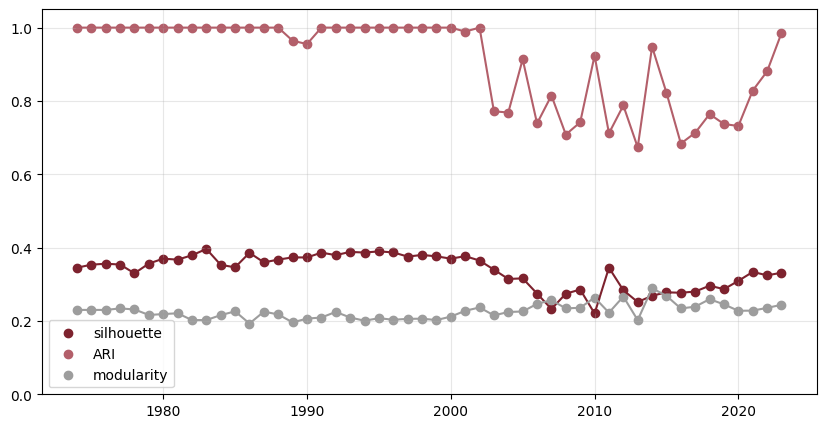

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

gtp.plot_clustering_scores(
    ax=ax,
    year_list=clustering._year_list,
    silhouette_score=clustering._silhouette_score,
    ari_score_mean=clustering._ari_score_mean,
    modularity=clustering._modularity,
    vertical_lines=[],
)

plt.show()

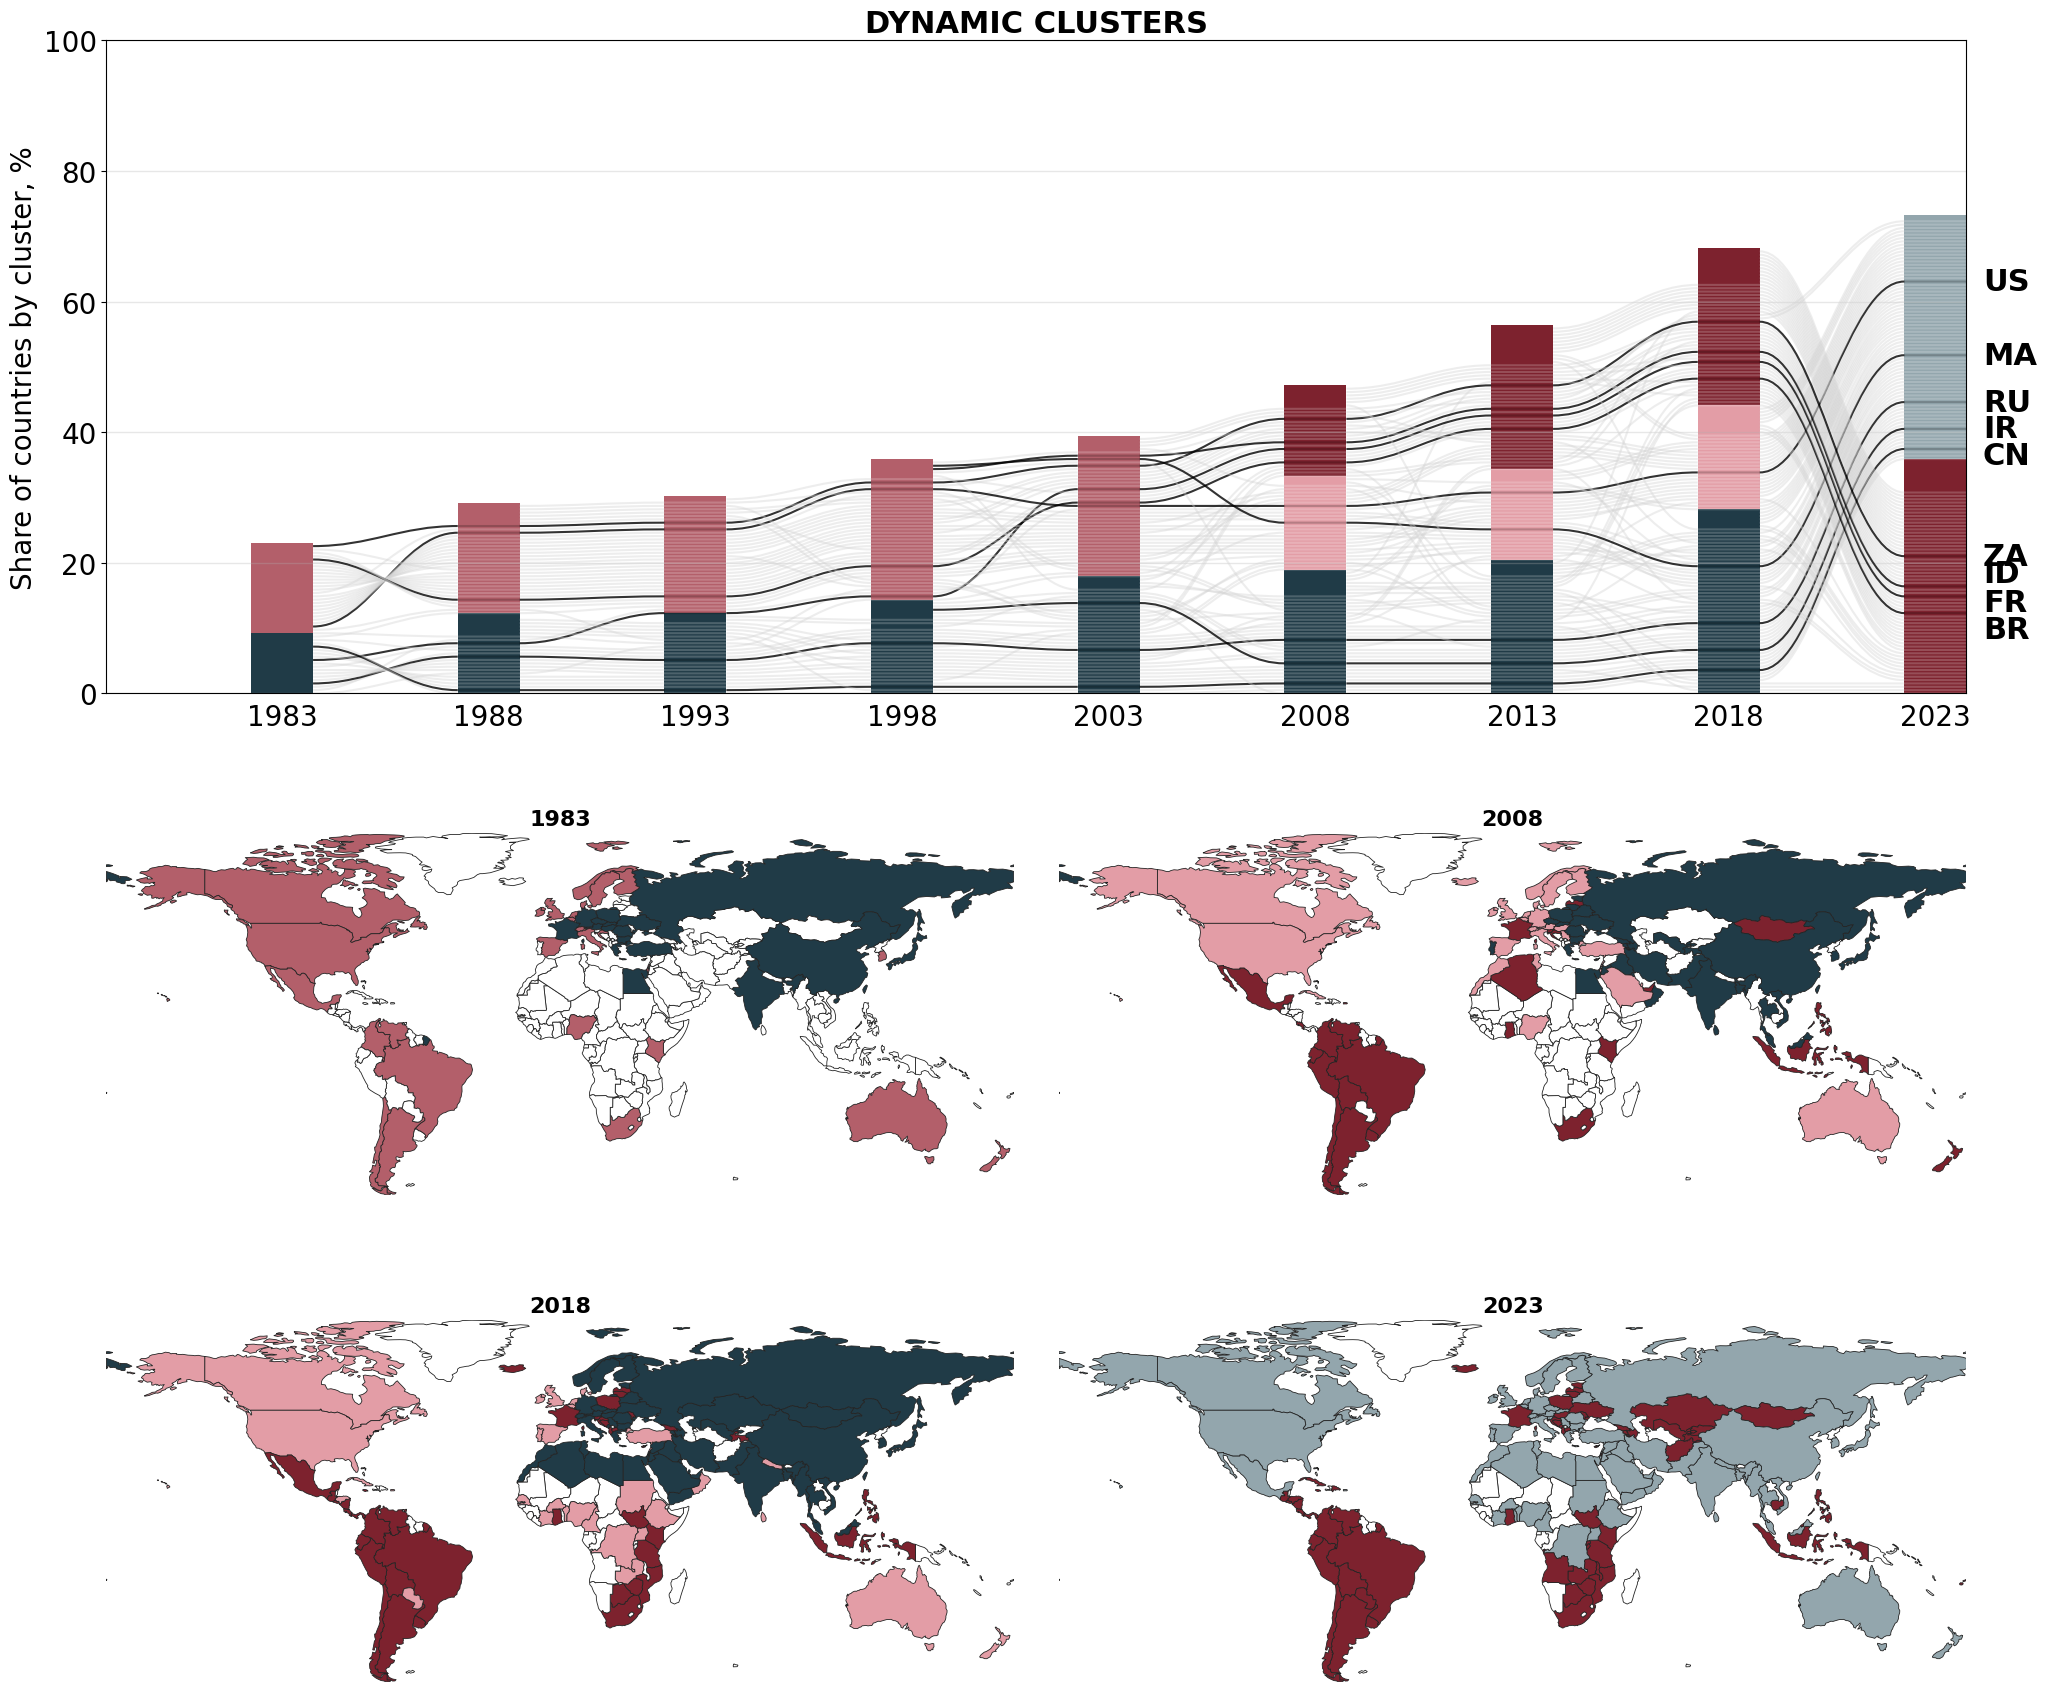

In [8]:
fig = plt.figure(figsize=(24, 22))

outer = fig.add_gridspec(
    4, 2,
    height_ratios=[1.4, 0.1, 1, 1],
    hspace=0.05,
    wspace=0.05,
)

ax_flow = fig.add_subplot(outer[0, :])

preprocessed = gtp.dyn_clusters_preprocess(
    df_mapping=clustering._df_mapping,
    year_list=year_list_10y,
    color_dict_tmp=color_dict_tmp,
)

country_info = gtp.dyn_clusters_country_info(
    preprocessed,
    country_list=["CN", "RU", "BR", "ZA", "US", "FR", "MA", "IR", "ID"],
)

gtp.dyn_clusters_plot(
    preprocessed,
    country_info,
    ax=ax_flow,
)

years=[1983, 2008, 2018, 2023]

for i, year in enumerate(years):
    ax = fig.add_subplot(outer[2+(i // 2), i % 2])
    gtp.plot_cluster_map(
        ax=ax,
        year=year,
        df_mapping=clustering._df_mapping,
        world=world,
        df_country=df_country,
        color_dict_tmp=color_dict_tmp,
        title_fontsize=16,
    )

plt.show()

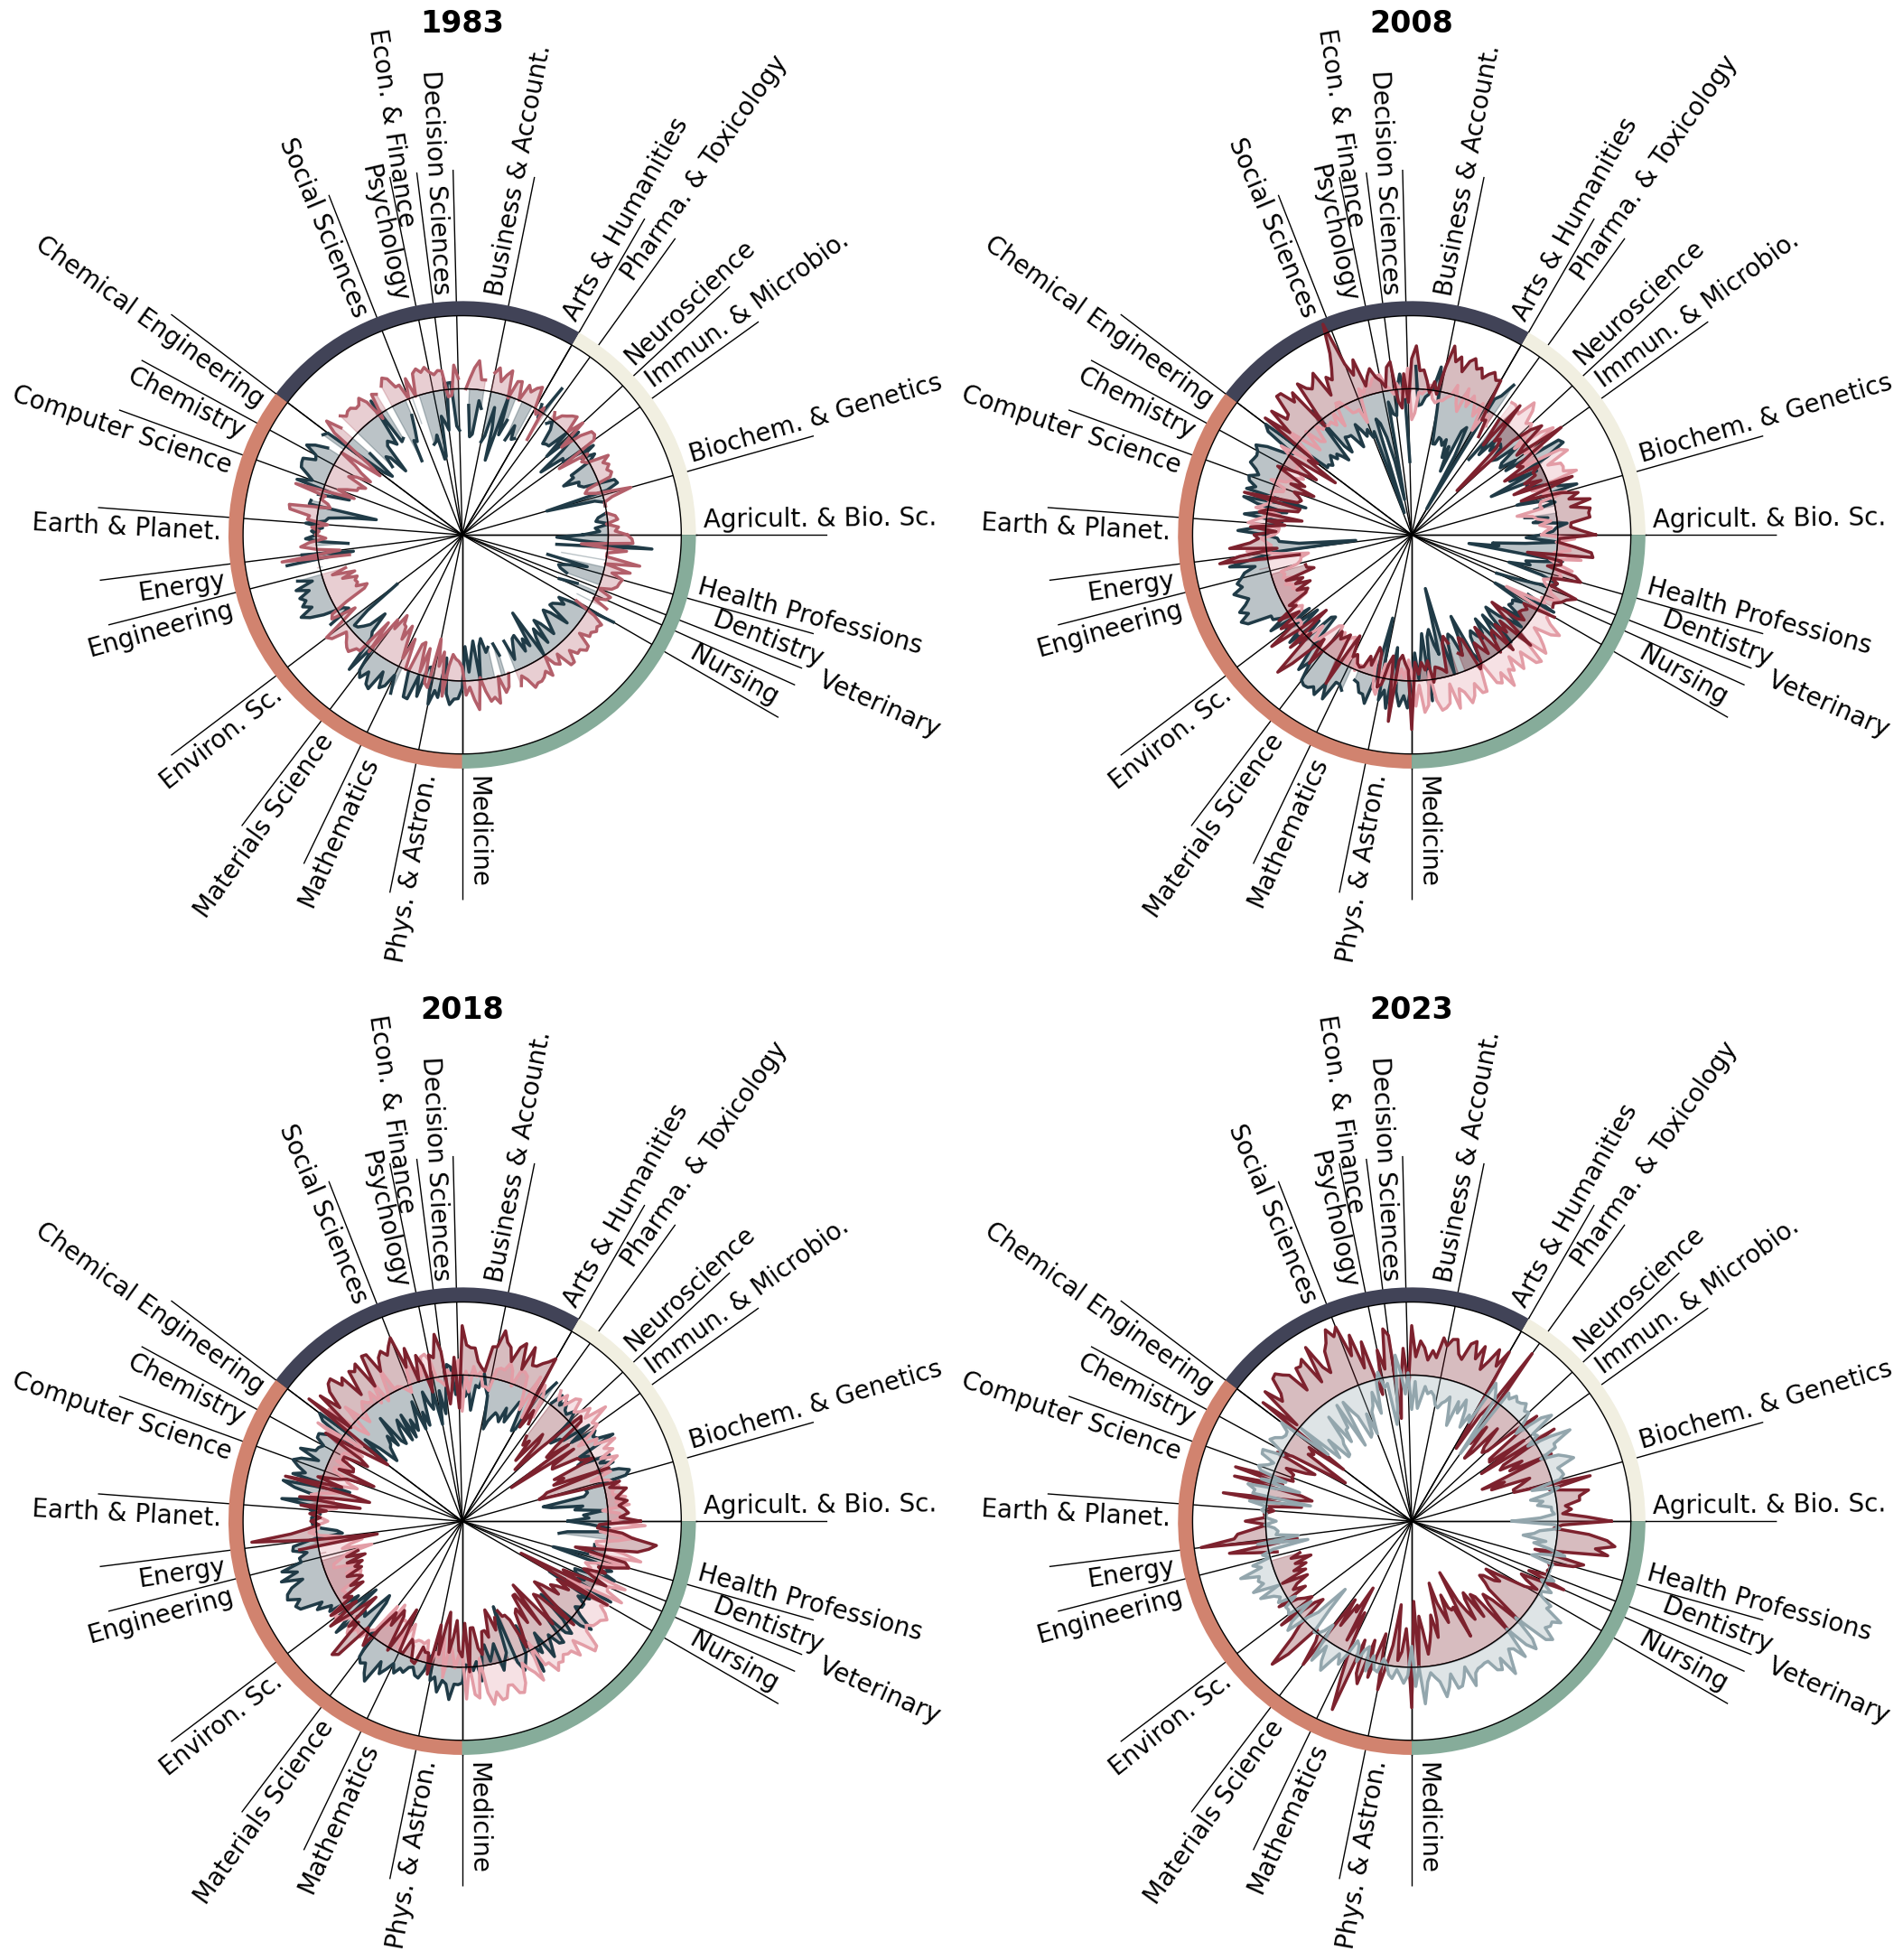

In [9]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(
    2, 2,
    subplot_kw={'projection': 'polar'},
    figsize=(24, 26)
)

gtp.draw_polar(ax1, interest_metric._df_metric.xs(1983)[sf_list], 1983, 10, color_dict_tmp)
gtp.draw_polar(ax2, interest_metric._df_metric.xs(2008)[sf_list], 2008, 10, color_dict_tmp)
gtp.draw_polar(ax3, interest_metric._df_metric.xs(2018)[sf_list], 2018, 10, color_dict_tmp)
gtp.draw_polar(ax4, interest_metric._df_metric.xs(2023)[sf_list], 2023, 10, color_dict_tmp)
fig.subplots_adjust(wspace=0.3)
# fig.savefig(f"../images/spec_all_v3.jpg", dpi=1000, bbox_inches='tight')